# Three-station continuous-audio tracking pilot

**TL;DR.** The complete synthetic chain (one continuous moving source, 12 microphone channels at three tetrahedral stations, all-frame GCC/SRP bearings, calibrated `BearingMeasurement`, causal retarded-time tracking) executed reproducibly. Bearing RMSE is about 0.46–0.49° at −6 dB and 0.081–0.083° at 10 dB. Ten of twelve method-sequences finish confirmed/valid; both CV/10 dB variants remain tentatively initialized. Conditional tracking error is 0.94–2.32 m, but covariance coverage is poor on manoeuvres. This is an offline integration pilot, not rare-tail qualification or real-time readiness.

## Frozen protocol and interpretation

The protocol is stored in `THREE_STATION_AUDIO_PROTOCOL.md`: three tetrahedral stations, 48 kHz, 1024/512 frames, 2 s sequences, random broadband source, SNR −6/10 dB, CV/acceleration/smooth-turn trajectories, and disjoint calibration/evaluation seeds. GCC and SRP process every frame. The dense-history tracker receives deterministic frame indices `0,32,64,...` (2.9297 Hz/station) for computational feasibility. One independent sequence per physical cell is a deliberately small pilot; overlapping frames are dependent and rare tails or sequence-level confidence intervals are not qualified.

In [1]:
from pathlib import Path
import csv, json, math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'results'

def load_csv(name):
    with (RESULTS / name).open(encoding='utf-8', newline='') as stream:
        return list(csv.DictReader(stream))

calibration = load_csv('three_station_audio_calibration.csv')
bearings = load_csv('three_station_audio_bearing_results.csv')
tracking = load_csv('three_station_audio_tracking_results.csv')
sequences = load_csv('three_station_audio_sequence_results.csv')
summary = load_csv('three_station_audio_summary.csv')
seed_rows = load_csv('three_station_audio_seed_provenance.csv')
len(calibration), len(bearings), len(tracking), len(sequences), len(summary), len(seed_rows)

(36, 6696, 216, 12, 12, 12)

In [2]:
assert (len(calibration), len(bearings), len(tracking), len(sequences), len(summary), len(seed_rows)) == (36, 6696, 216, 12, 12, 12)
assert all(row['truth_used_by_audio_estimator'] == 'False' for row in bearings)
assert all(row['truth_used_by_tracker'] == 'False' for row in tracking)
assert all(int(row['event_count']) == 18 for row in sequences)
sequence_seeds = {split: {int(row['sequence_seed']) for row in seed_rows if row['split'] == split} for split in ('calibration', 'evaluation')}
role_seeds = {split: set() for split in sequence_seeds}
for row in seed_rows:
    values = [int(row['source_seed']), *map(int, json.loads(row['noise_seeds_json']))]
    assert len(values) == len(set(values))
    assert not role_seeds[row['split']].intersection(values)
    role_seeds[row['split']].update(values)
assert sequence_seeds['calibration'].isdisjoint(sequence_seeds['evaluation'])
assert role_seeds['calibration'].isdisjoint(role_seeds['evaluation'])
minimum_eigenvalue = min(float(row['eigenvalue_min_rad2']) for row in calibration)
maximum_temporal_correlation = max(abs(float(row[key])) for row in calibration for key in ('temporal_lag1_az', 'temporal_lag1_el'))
maximum_interstation_correlation = max(abs(float(row['maximum_absolute_interstation_correlation'])) for row in calibration)
assert minimum_eigenvalue > 0.0
display(Markdown(f'**Audit PASS:** no seed overlap; all calibration covariances are PD (minimum eigenvalue `{minimum_eigenvalue:.3e} rad²`). Maximum absolute lag-1/inter-station correlations are `{maximum_temporal_correlation:.3f}` / `{maximum_interstation_correlation:.3f}`.'))

**Audit PASS:** no seed overlap; all calibration covariances are PD (minimum eigenvalue `7.777e-07 rad²`). Maximum absolute lag-1/inter-station correlations are `0.456` / `0.202`.

In [3]:
lines = ['| Trajectory | SNR (dB) | Method | Bearing RMSE (deg) | Final valid | Confirmed publications | Position RMSE (m) | Velocity RMSE (m/s) | Coverage |', '|---|---:|---|---:|---:|---:|---:|---:|---:|']
for row in summary:
    def fmt(key, digits=3):
        value = float(row[key])
        return '—' if not np.isfinite(value) else f'{value:.{digits}f}'
    lines.append(f"| {row['trajectory_kind']} | {float(row['snr_db']):.0f} | {row['estimator_variant']} | {fmt('bearing_rmse_deg_conditional')} | {fmt('final_valid_sequence_fraction', 2)} | {fmt('confirmed_publication_fraction', 2)} | {fmt('position_rmse_m_conditional')} | {fmt('velocity_rmse_mps_conditional')} | {fmt('coverage_conditional', 2)} |")
display(Markdown('## Numerical summary\n\n' + '\n'.join(lines)))

## Numerical summary

| Trajectory | SNR (dB) | Method | Bearing RMSE (deg) | Final valid | Confirmed publications | Position RMSE (m) | Velocity RMSE (m/s) | Coverage |
|---|---:|---|---:|---:|---:|---:|---:|---:|
| constant_velocity | -6 | all_6_equal_gcc_wls | 0.459 | 1.00 | 0.50 | 0.948 | 0.734 | 1.00 |
| constant_velocity | -6 | equal_weight_srp_phat | 0.457 | 1.00 | 0.50 | 0.939 | 0.728 | 1.00 |
| constant_velocity | 10 | all_6_equal_gcc_wls | 0.083 | 0.00 | 0.00 | — | — | — |
| constant_velocity | 10 | equal_weight_srp_phat | 0.083 | 0.00 | 0.00 | — | — | — |
| constant_acceleration_segment | -6 | all_6_equal_gcc_wls | 0.491 | 1.00 | 0.50 | 1.921 | 2.598 | 0.67 |
| constant_acceleration_segment | -6 | equal_weight_srp_phat | 0.487 | 1.00 | 0.50 | 1.853 | 2.537 | 0.67 |
| constant_acceleration_segment | 10 | all_6_equal_gcc_wls | 0.082 | 1.00 | 0.50 | 1.178 | 1.557 | 0.00 |
| constant_acceleration_segment | 10 | equal_weight_srp_phat | 0.082 | 1.00 | 0.50 | 1.179 | 1.558 | 0.00 |
| smooth_turn | -6 | all_6_equal_gcc_wls | 0.471 | 1.00 | 0.50 | 2.319 | 2.640 | 0.00 |
| smooth_turn | -6 | equal_weight_srp_phat | 0.470 | 1.00 | 0.50 | 2.292 | 2.648 | 0.00 |
| smooth_turn | 10 | all_6_equal_gcc_wls | 0.081 | 1.00 | 0.50 | 2.296 | 3.286 | 0.00 |
| smooth_turn | 10 | equal_weight_srp_phat | 0.081 | 1.00 | 0.50 | 2.297 | 3.287 | 0.00 |

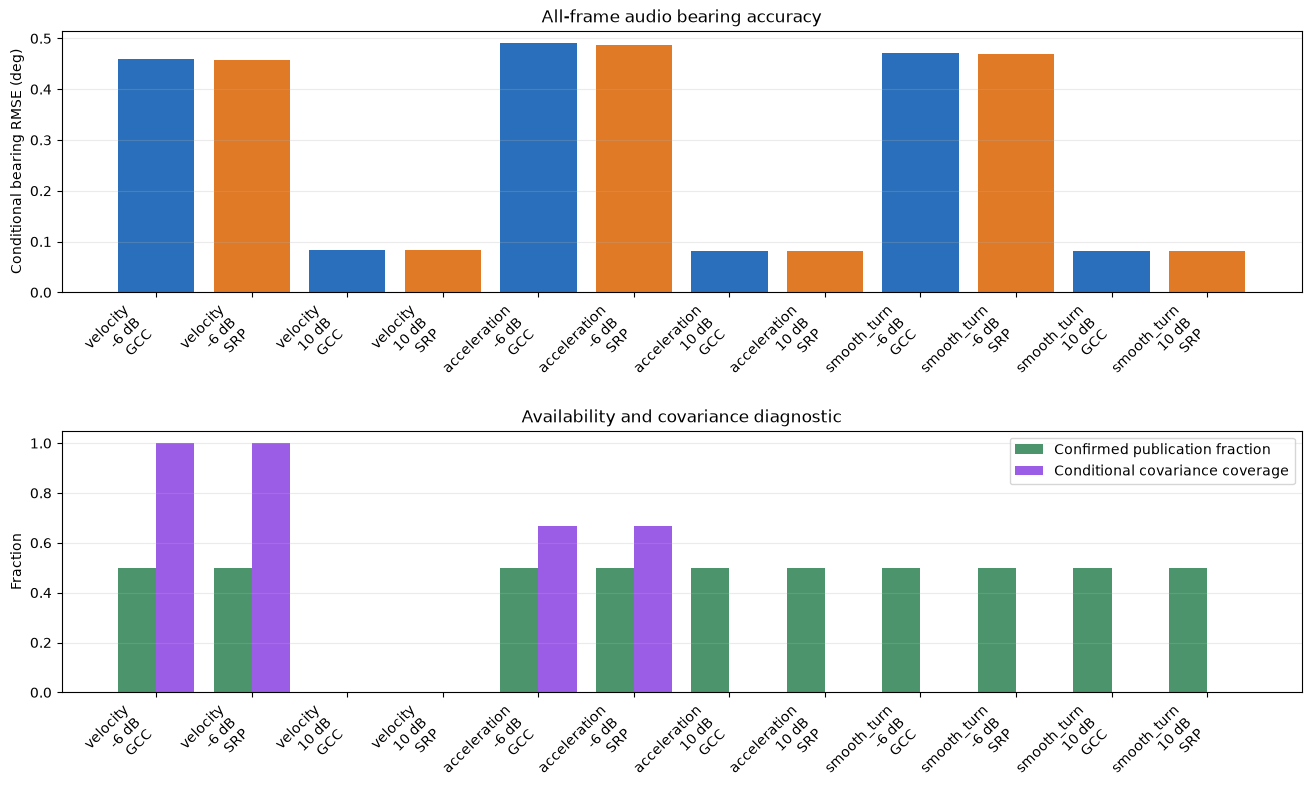

In [4]:
labels = [f"{row['trajectory_kind'].replace('constant_', '').replace('_segment','')}\n{float(row['snr_db']):.0f} dB\n{'GCC' if row['estimator_variant'].startswith('all_6') else 'SRP'}" for row in summary]
bearing_rmse = np.array([float(row['bearing_rmse_deg_conditional']) for row in summary])
position_rmse = np.array([float(row['position_rmse_m_conditional']) for row in summary])
confirmed = np.array([float(row['confirmed_publication_fraction']) for row in summary])
coverage = np.array([float(row['coverage_conditional']) for row in summary])
x = np.arange(len(summary))
fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)
axes[0].bar(x, bearing_rmse, color=['#2a6fbb' if 'gcc' in row['estimator_variant'] else '#e07a26' for row in summary])
axes[0].set_ylabel('Conditional bearing RMSE (deg)')
axes[0].set_title('All-frame audio bearing accuracy')
axes[0].grid(axis='y', alpha=0.25)
axes[0].set_xticks(x, labels, rotation=45, ha='right')
axes[1].bar(x - 0.2, confirmed, width=0.4, label='Confirmed publication fraction', color='#4c956c')
axes[1].bar(x + 0.2, np.nan_to_num(coverage, nan=0.0), width=0.4, label='Conditional covariance coverage', color='#9b5de5')
axes[1].set_ylabel('Fraction')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Availability and covariance diagnostic')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
axes[1].set_xticks(x, labels, rotation=45, ha='right')
plt.show()

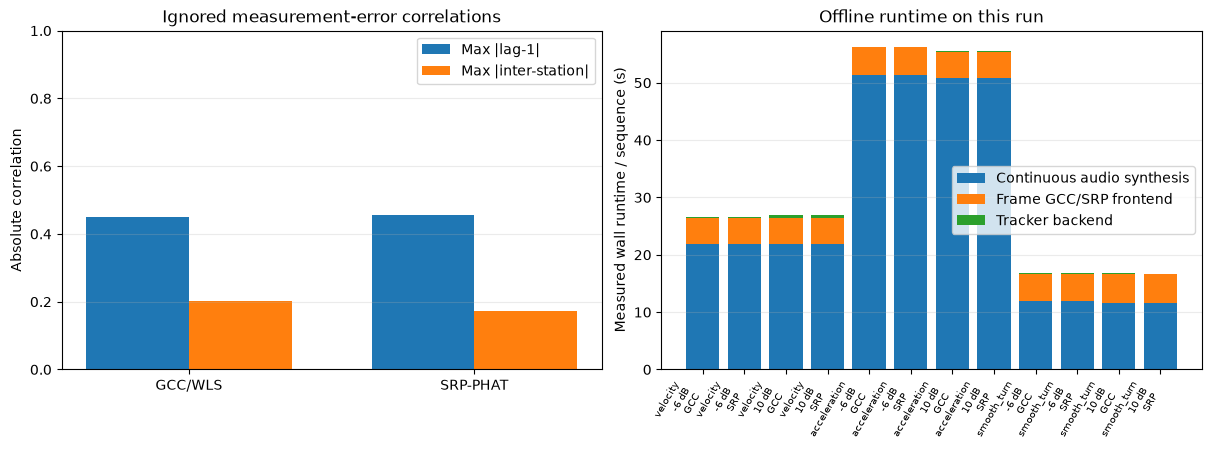

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
methods = ['all_6_equal_gcc_wls', 'equal_weight_srp_phat']
method_labels = ['GCC/WLS', 'SRP-PHAT']
temporal = [max(abs(float(row[k])) for row in calibration if row['estimator_variant'] == method for k in ('temporal_lag1_az', 'temporal_lag1_el')) for method in methods]
interstation = [max(abs(float(row['maximum_absolute_interstation_correlation'])) for row in calibration if row['estimator_variant'] == method) for method in methods]
mx = np.arange(2)
axes[0].bar(mx - 0.18, temporal, 0.36, label='Max |lag-1|')
axes[0].bar(mx + 0.18, interstation, 0.36, label='Max |inter-station|')
axes[0].set_xticks(mx, method_labels)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Absolute correlation')
axes[0].set_title('Ignored measurement-error correlations')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.25)
synthesis = [float(row['mean_audio_synthesis_wall_runtime_s_per_sequence']) for row in summary]
front = [float(row['mean_bearing_frontend_wall_runtime_s_per_sequence']) for row in summary]
back = [float(row['mean_tracker_runtime_s_per_sequence']) for row in summary]
axes[1].bar(x, synthesis, label='Continuous audio synthesis')
axes[1].bar(x, front, bottom=synthesis, label='Frame GCC/SRP frontend')
axes[1].bar(x, back, bottom=np.asarray(synthesis) + np.asarray(front), label='Tracker backend')
axes[1].set_ylabel('Measured wall runtime / sequence (s)')
axes[1].set_title('Offline runtime on this run')
axes[1].set_xticks(x, labels, rotation=60, ha='right', fontsize=7)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.25)
plt.show()

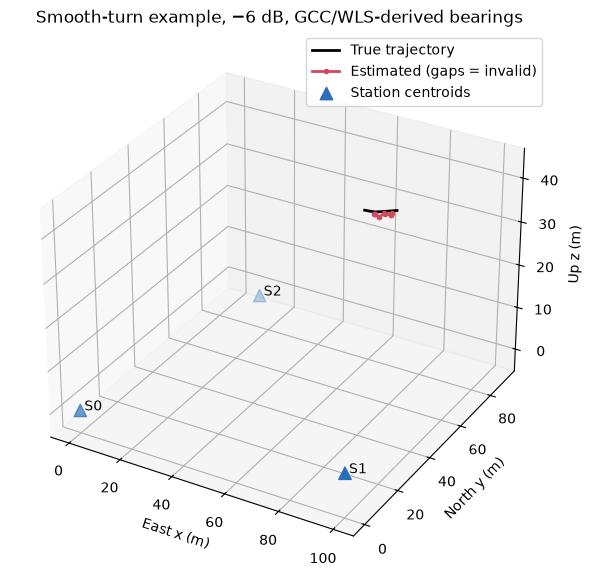

In [6]:
chosen = [row for row in tracking if row['trajectory_kind'] == 'smooth_turn' and row['snr_db'] == '-6.0' and row['estimator_variant'] == 'all_6_equal_gcc_wls']
chosen.sort(key=lambda row: float(row['processing_time_s']))
truth = np.array([[float(row[f'truth_position_{axis}_m']) for axis in 'xyz'] for row in chosen])
estimate = np.array([[float(row[f'estimate_position_{axis}_m']) for axis in 'xyz'] for row in chosen])
valid = np.array([row['valid'] == 'True' for row in chosen])
estimate[~valid] = np.nan  # visible gaps: no interpolation through invalid tracking
stations = np.array([[0., 0., 0.], [100., 0., 5.], [10., 90., -2.]])
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(*truth.T, color='black', linewidth=2, label='True trajectory')
ax.plot(*estimate.T, color='#d1495b', linewidth=2, marker='o', markersize=3, label='Estimated (gaps = invalid)')
ax.scatter(*stations.T, color='#2a6fbb', marker='^', s=80, label='Station centroids')
for index, station in enumerate(stations):
    ax.text(*station, f' S{index}')
ax.set_xlabel('East x (m)'); ax.set_ylabel('North y (m)'); ax.set_zlabel('Up z (m)')
ax.set_title('Smooth-turn example, −6 dB, GCC/WLS-derived bearings')
ax.legend()
plt.show()

## Takeaways and limitations

- The end-to-end chain uses directions estimated from shared continuous audio; truth is confined to synthesis and offline scoring. Reception-frame centres, frame-end acquisition, modeled processing/delivery delay and measured runtime remain distinct.
- GCC/WLS and equal-weight SRP-PHAT are very close in this small synthetic pilot. This is not evidence of equivalence in field data.
- Two CV/10 dB method-streams fail to confirm despite lower bearing error. This illustrates that initialization/calibration consistency, not bearing RMSE alone, controls availability.
- Covariance coverage is inadequate on manoeuvres (often zero), and lag-1 correlation reaches about 0.456. The current filter assumes independent bearing errors, so its covariance must not be treated as calibrated for this signal chain.
- The tracker consumes every 32nd frame for computational feasibility. The implementation is an offline pilot, not real-time ready. The experiment has only one independent sequence per cell and cannot characterize rare tails.
- The propagation medium remains homogeneous and stationary; reflections, wind, correlated background, source radiation calibration and field validation are out of scope.